# Employee Attrition Prediction — Machine Learning Phase

## Objective

The objective of this notebook is to develop machine learning models for predicting employee attrition.

This phase includes:

1. Data Loading
2. Data Preprocessing
3. Feature Encoding
4. Train-Test Split
5. Model Training
6. Model Evaluation
7. Model Comparison
8. Best Model Selection
9. Model Saving

In [1]:
# ==========================================
# Importing Required Libraries
# ==========================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.model_selection import train_test_split

In [2]:
#=====================================
# Loading Dataset
#=====================================

# Reading employee attrition dataset

df = pd.read_csv('../dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Displaying first 5 rows

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Data Preprocessing & Feature Engineering

In [3]:
# ==========================================
# Checking Dataset Shape and Information
# ==========================================

# Checking number of rows and columns

print("Dataset Shape:", df.shape)

# Checking dataset information

df.info()

Dataset Shape: (1470, 35)
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                 

In [4]:
# ===================================
# FEATURE SELECTION
# ===================================

selected_features = [

    "Age",
    "MonthlyIncome",
    "DistanceFromHome",

    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "WorkLifeBalance",

    "OverTime",

    "JobInvolvement",
    "RelationshipSatisfaction",

    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",

    "NumCompaniesWorked",

    "StockOptionLevel",

    "TrainingTimesLastYear",

    "PercentSalaryHike",

    "BusinessTravel",
    "Department",
    "JobRole",
    "MaritalStatus"
]

target = "Attrition"

ml_df = df[selected_features + [target]]

print("Features Selected:", len(selected_features))
print("Dataset Shape:", ml_df.shape)

ml_df.head()

Features Selected: 22
Dataset Shape: (1470, 23)


,Age,MonthlyIncome,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,OverTime,JobInvolvement,RelationshipSatisfaction,TotalWorkingYears,...,YearsWithCurrManager,NumCompaniesWorked,StockOptionLevel,TrainingTimesLastYear,PercentSalaryHike,BusinessTravel,Department,JobRole,MaritalStatus,Attrition
0,41,5993,1,4,2,1,Yes,3,1,8,...,5,8,0,0,11,Travel_Rarely,Sales,Sales Executive,Single,Yes
1,49,5130,8,2,3,3,No,2,4,10,...,7,1,1,3,23,Travel_Frequently,Research & Development,Research Scientist,Married,No
2,37,2090,2,3,4,3,Yes,2,2,7,...,0,6,0,3,15,Travel_Rarely,Research & Development,Laboratory Technician,Single,Yes
3,33,2909,3,3,4,3,Yes,3,3,8,...,0,1,0,3,11,Travel_Frequently,Research & Development,Research Scientist,Married,No
4,27,3468,2,2,1,3,No,3,4,6,...,2,9,1,3,12,Travel_Rarely,Research & Development,Laboratory Technician,Married,No


## Feature Selection

To improve model interpretability and deployment efficiency, a subset of meaningful HR-related features was selected from the original dataset.

The selected features were chosen based on their potential impact on employee attrition, including:

- Demographic factors (Age, Marital Status)
- Compensation factors (Monthly Income, Stock Option Level)
- Job-related factors (Department, Job Role, Job Involvement)
- Satisfaction indicators (Job Satisfaction, Environment Satisfaction, Work-Life Balance)
- Career progression indicators (Years At Company, Years Since Last Promotion)
- Work conditions (Business Travel, Overtime)

Reducing the feature space helps:

- Improve model efficiency
- Reduce noise
- Improve deployment compatibility
- Enhance model interpretability

## Feature Encoding

Machine learning algorithms require numerical input data.

Categorical variables such as:

- BusinessTravel
- Department
- JobRole
- MaritalStatus
- OverTime

were transformed using One-Hot Encoding.

The `drop_first=True` parameter was used to avoid multicollinearity and reduce redundant feature creation.

In [5]:
# ===================================
# ENCODING CATEGORICAL FEATURES
# ===================================

ml_df_encoded = pd.get_dummies(
    ml_df,
    drop_first=True
)

print("Encoded Dataset Shape:")
print(ml_df_encoded.shape)

ml_df_encoded.head()

Encoded Dataset Shape:
(1470, 33)


,Age,MonthlyIncome,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,JobInvolvement,RelationshipSatisfaction,TotalWorkingYears,YearsAtCompany,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,Attrition_Yes
0,41,5993,1,4,2,1,3,1,8,6,...,False,False,False,False,False,True,False,False,True,True
1,49,5130,8,2,3,3,2,4,10,10,...,False,False,False,False,True,False,False,True,False,False
2,37,2090,2,3,4,3,2,2,7,0,...,True,False,False,False,False,False,False,False,True,True
3,33,2909,3,3,4,3,3,3,8,8,...,False,False,False,False,True,False,False,True,False,False
4,27,3468,2,2,1,3,3,4,6,2,...,True,False,False,False,False,False,False,True,False,False


In [6]:
# ===================================
# SPLIT FEATURES & TARGET
# ===================================

X = ml_df_encoded.drop(
    "Attrition_Yes",
    axis=1
)

y = ml_df_encoded[
    "Attrition_Yes"
]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1470, 32)
y Shape: (1470,)


In [7]:
ml_df.shape

(1470, 23)

In [8]:
ml_df_encoded.shape

(1470, 33)

In [9]:
X.shape

(1470, 32)

In [10]:
y.value_counts()

Attrition_Yes
False    1233
True      237
Name: count, dtype: int64

## Train Test Split

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
# ===================================
# TRAIN TEST SPLIT
# ===================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features: (1176, 32)
Testing Features : (294, 32)
Training Labels : (1176,)
Testing Labels  : (294,)


In [13]:
print(y_train.value_counts())
print(y_test.value_counts())

Attrition_Yes
False    986
True     190
Name: count, dtype: int64
Attrition_Yes
False    247
True      47
Name: count, dtype: int64


## Class Imbalance Handling

Employee attrition datasets are naturally imbalanced because most employees remain in the organization while relatively fewer employees leave.

Class distribution before balancing:

- Stay Employees: Majority Class
- Attrition Employees: Minority Class

To address this issue, SMOTE (Synthetic Minority Oversampling Technique) was applied only to the training dataset.

Benefits of SMOTE:

- Improves minority class learning
- Reduces model bias toward majority class
- Improves recall for attrition prediction

In [14]:
from imblearn.over_sampling import SMOTE

In [15]:
# =====================================
# BALANCING TRAINING DATA USING SMOTE
# =====================================

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
Attrition_Yes
False    986
True     190
Name: count, dtype: int64

After SMOTE
Attrition_Yes
False    986
True     986
Name: count, dtype: int64


## Model 1: Logistic Regression

Logistic Regression serves as a baseline classification model.

Advantages:

- Fast training
- High interpretability
- Good baseline performance

This model establishes a benchmark against which more advanced models can be compared.

In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
# =====================================
# LOGISTIC REGRESSION
# =====================================

lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_model.fit(
    X_train_smote,
    y_train_smote
)

print("Logistic Regression Trained Successfully")

Logistic Regression Trained Successfully


C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [19]:
lr_pred = lr_model.predict(X_test)

lr_prob = lr_model.predict_proba(X_test)[:, 1]

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1 Score:",
      f1_score(y_test, lr_pred))

print("ROC AUC:",
      roc_auc_score(y_test, lr_prob))

Accuracy: 0.8163265306122449
Precision: 0.42857142857142855
Recall: 0.44680851063829785
F1 Score: 0.4375
ROC AUC: 0.7334826427771557


## Model 2: Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Advantages:

- Handles non-linear relationships
- Reduces overfitting
- Provides feature importance scores

This model is expected to outperform Logistic Regression for complex employee attrition patterns.

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
# =====================================
# RANDOM FOREST
# =====================================

rf_model = RandomForestClassifier(

    n_estimators=300,

    max_depth=10,

    random_state=42,

    n_jobs=-1

)

rf_model.fit(

    X_train_smote,

    y_train_smote

)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [22]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Precision:",
      precision_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("F1 Score:",
      f1_score(y_test, rf_pred))

print("ROC AUC:",
      roc_auc_score(y_test, rf_prob))

Accuracy: 0.8231292517006803
Precision: 0.42857142857142855
Recall: 0.3191489361702128
F1 Score: 0.36585365853658536
ROC AUC: 0.7546730984580929


## Model 3: Extreme Gradient Boosting (XGBoost)

XGBoost is a powerful gradient boosting framework widely used in industry and machine learning competitions.

Advantages:

- High predictive performance
- Built-in regularization
- Efficient handling of complex feature interactions
- Strong performance on tabular datasets

XGBoost was evaluated against Logistic Regression and Random Forest to determine the best-performing model.

Class imbalance was further addressed using:

- SMOTE Oversampling
- XGBoost Positive Class Weighting (scale_pos_weight)

This improved the model's ability to identify potential employee attrition cases.

In [23]:
from xgboost import XGBClassifier

In [24]:
# =====================================
# XGBOOST
# =====================================

negative = (y_train_smote == 0).sum()
positive = (y_train_smote == 1).sum()

scale_pos_weight = negative / positive

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_smote, y_train_smote)

print("XGBoost Trained Successfully")

XGBoost Trained Successfully


## Model Comparison

The performance of all trained models was evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

The objective was to identify the model that provides the best overall balance between predictive accuracy and attrition detection capability.

In [25]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:,1]

print("Accuracy:",
      accuracy_score(y_test, xgb_pred))

print("Precision:",
      precision_score(y_test, xgb_pred))

print("Recall:",
      recall_score(y_test, xgb_pred))

print("F1 Score:",
      f1_score(y_test, xgb_pred))

print("ROC AUC:",
      roc_auc_score(y_test, xgb_prob))

Accuracy: 0.8435374149659864
Precision: 0.5135135135135135
Recall: 0.40425531914893614
F1 Score: 0.4523809523809524
ROC AUC: 0.776121974330261


In [26]:
# Logistic Regression Metrics

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_roc = roc_auc_score(y_test, lr_prob)

# Random Forest Metrics

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc = roc_auc_score(y_test, rf_prob)

# XGBoost Metrics

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc = roc_auc_score(y_test, xgb_prob)

In [27]:
comparison_df = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision":[
        lr_precision,
        rf_precision,
        xgb_precision
    ],

    "Recall":[
        lr_recall,
        rf_recall,
        xgb_recall
    ],

    "F1":[
        lr_f1,
        rf_f1,
        xgb_f1
    ],

    "ROC_AUC":[
        lr_roc,
        rf_roc,
        xgb_roc
    ]

})

comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.816327,0.428571,0.446809,0.437500,0.733483
1,Random Forest,0.823129,0.428571,0.319149,0.365854,0.754673
2,XGBoost,0.843537,0.513514,0.404255,0.452381,0.776122


## Confusion Matrix Analysis

A confusion matrix provides a detailed breakdown of model predictions.

It shows:

- True Positives (Correct Attrition Predictions)
- True Negatives (Correct Retention Predictions)
- False Positives
- False Negatives

This analysis helps evaluate how effectively the model identifies employees who are likely to leave.

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

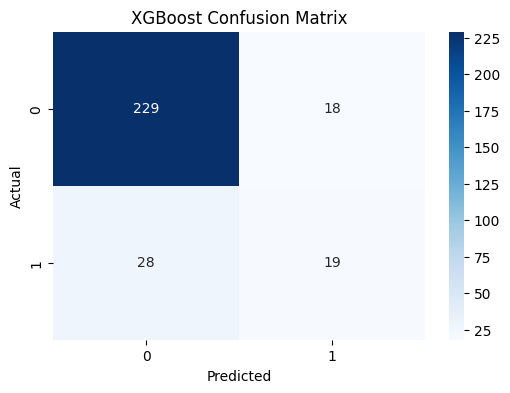

In [29]:
# =====================================
# CONFUSION MATRIX - XGBOOST
# =====================================

cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Feature Importance Analysis

Feature importance analysis helps identify which employee characteristics contribute most to attrition prediction.

Understanding feature importance provides:

- Business insights
- HR decision-making support
- Increased model transparency

The top-ranked features can be used by organizations to proactively address employee retention challenges.

In [30]:
# =====================================
# FEATURE IMPORTANCE
# =====================================

importance_df = pd.DataFrame({

    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
14,StockOptionLevel,0.102786
30,MaritalStatus_Married,0.092051
21,Department_Sales,0.067785
31,MaritalStatus_Single,0.052010
20,Department_Research & Development,0.048995
3,JobSatisfaction,0.045891
22,JobRole_Human Resources,0.041848
4,EnvironmentSatisfaction,0.038662
5,WorkLifeBalance,0.037403
27,JobRole_Research Scientist,0.035159


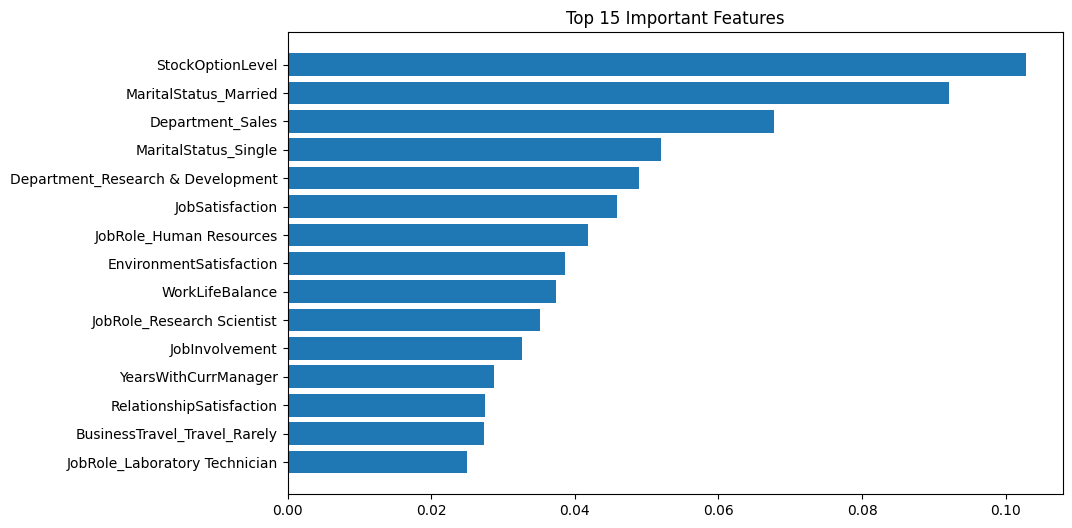

In [31]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"].head(15),
    importance_df["Importance"].head(15)
)

plt.title("Top 15 Important Features")

plt.gca().invert_yaxis()

plt.show()

## Final Model Selection & Model Saving

Based on the comparative evaluation of all machine learning models, XGBoost achieved the strongest overall performance and was selected as the final deployment model.

The following artifacts were saved:

### xgboost_model.pkl

Contains the trained XGBoost classifier used for employee attrition prediction.

### feature_names.pkl

Contains the complete feature structure expected by the deployed model.

These files will be utilized by the Flask backend during real-time prediction.

In [32]:
import joblib

In [33]:
import joblib

joblib.dump(
    xgb_model,
    "../model/xgboost_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [34]:
joblib.dump(
    X.columns.tolist(),
    "../model/feature_names.pkl"
)

print("Feature Names Saved Successfully")

Feature Names Saved Successfully


In [35]:
feature_names = joblib.load(
    "../model/feature_names.pkl"
)

print("Total Features:", len(feature_names))

feature_names[:10]

Total Features: 32


['Age',
 'MonthlyIncome',
 'DistanceFromHome',
 'JobSatisfaction',
 'EnvironmentSatisfaction',
 'WorkLifeBalance',
 'JobInvolvement',
 'RelationshipSatisfaction',
 'TotalWorkingYears',
 'YearsAtCompany']

In [36]:
import json

defaults = {

    "jobinvolvement": int(df["JobInvolvement"].median()),
    "relationshipsatisfaction": int(df["RelationshipSatisfaction"].median()),
    "stockoptionlevel": int(df["StockOptionLevel"].median()),
    "trainingtimeslastyear": int(df["TrainingTimesLastYear"].median()),
    "percentsalaryhike": int(df["PercentSalaryHike"].median()),

    "totalworkingyears": int(df["TotalWorkingYears"].median()),
    "yearsatcompany": int(df["YearsAtCompany"].median()),
    "yearsincurrentrole": int(df["YearsInCurrentRole"].median()),
    "yearssincelastpromotion": int(df["YearsSinceLastPromotion"].median()),
    "yearswithcurrentmanager": int(df["YearsWithCurrManager"].median()),

    "numcompaniesworked": int(df["NumCompaniesWorked"].median()),

    "overtime": "No"
}

with open("../notebook/defaults.json", "w") as f:
    json.dump(defaults, f, indent=4)

print("Defaults Saved Successfully")

Defaults Saved Successfully


## Threshold Configuration

The optimal classification threshold was selected based on F1-score and recall evaluation.

The threshold value is exported separately and will be used by the Flask application during deployment.

In [37]:
import json

threshold_data = {
    "threshold": 0.40
}

with open("../model/threshold.json", "w") as f:
    json.dump(threshold_data, f, indent=4)

print("Threshold Saved Successfully")

Threshold Saved Successfully


## Deployment Readiness Validation

The final model was validated using multiple employee profiles representing both low-risk and high-risk attrition scenarios.

Prediction probabilities were reviewed to ensure that the trained model could effectively differentiate between employees likely to remain and employees likely to leave.

After validation, the final model artifacts were exported for integration with the web application.

# Conclusion

Three machine learning models were developed and evaluated for employee attrition prediction:

1. Logistic Regression
2. Random Forest
3. XGBoost

After performance comparison, XGBoost demonstrated the best overall predictive capability and was selected as the final deployment model.

The trained model and feature structure were successfully exported for integration into a Flask-based web application.

This project demonstrates the complete machine learning workflow:

- Data Preprocessing
- Feature Engineering
- Class Balancing
- Model Training
- Model Evaluation
- Model Interpretation
- Model Deployment Preparation